# Assignment 1 - Step 1

In [451]:
#Import relevant libraries
import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [452]:
# import wind CF data for 6 windfarms and cut to be 24 hours and average out

W1_data = pd.read_csv('data_from_Jakob\scen_zone1.csv')
W1_CF = W1_data.iloc[1:25, 1:].mean(axis=1)

W2_data = pd.read_csv('data_from_Jakob\scen_zone2.csv')
W2_CF = W2_data.iloc[1:25, 1:].mean(axis=1)

W3_data = pd.read_csv('data_from_Jakob\scen_zone3.csv')
W3_CF = W3_data.iloc[1:25, 1:].mean(axis=1)

W4_data = pd.read_csv('data_from_Jakob\scen_zone4.csv')
W4_CF = W4_data.iloc[1:25, 1:].mean(axis=1)

W5_data = pd.read_csv('data_from_Jakob\scen_zone5.csv')
W5_CF = W5_data.iloc[1:25, 1:].mean(axis=1)

W6_data = pd.read_csv('data_from_Jakob\scen_zone6.csv')
W6_CF = W6_data.iloc[1:25, 1:].mean(axis=1)


In [453]:
from data import load_distribution, load_profile, generators, generator_bid_prices
from data import Prices_for_loads

#create variable list with the names of the variables as strings
VARIABLES = list(generators.keys())

LOAD_VARIABLES = list(load_distribution.keys())


#create a list of the cost coefficients for each variable
Generation_price = [v[1] for v in generator_bid_prices.values()]

#writes a list that converts the cost coefficient to this form objective_coeff = {'G1': 13.32, 'G2': 13.32, ...}
objective_coeff = {VARIABLES[i]: Generation_price[i] for i in range(len(VARIABLES))}


#write the load percentages for each node
Load_percentage = [v['percent'] for v in load_distribution.values()]
#multiply the load percentage with the total load to get the actual load in MW
hour1_load = load_profile[1] #MW
#hour1_load = 2650.5 #Max demand check only used for testing
#Load upper bound list for each load variable
Load = [hour1_load * (i / 100) for i in Load_percentage] #MW


#random price list with 17 values and sort it in descending order
#change prices for clarity in the plot
Randonm_prices_h1 = Prices_for_loads[1]
Demand_price= np.array(sorted(Randonm_prices_h1, reverse=True)) -60 #$/MWh 

#writes a list that converts the load coefficient to this form objective_coeff = {'Load1': 13.32, 'Load2': 13.32, ...}
Load_coefficients = {LOAD_VARIABLES[i]: Demand_price[i] for i in range(len(LOAD_VARIABLES))}

#create a upper bound for the production variables
Generator_UB = [v['Pmax_MW'] for k, v in generators.items() if k.startswith('G')]

#Generator_UB = [152,152,350,591,60,155,155,400,400,300,310,350] #MW
Wind_UB = np.array([W1_CF[1], W2_CF[1], W3_CF[1], W4_CF[1],W5_CF[1],W6_CF[1]])*200
Constraints_rhs = Generator_UB + Wind_UB.tolist()
#create constraints sense list with 18 values of GRB.LESS_EQUAL
constraints_sense = [GRB.LESS_EQUAL] * 18




In [454]:
#Create model
model = gp.Model("Copperplate_singlehour")

In [455]:
#Add variables
variables = {v: model.addVar(lb=0, name=f'variable {v}') for v in VARIABLES}

#Add load variables
load_variables = {l: model.addVar(lb=0, name=f'variable {l}') for l in LOAD_VARIABLES}

In [456]:
# Set objective function and optimization direction of the Gurobi model
objective = gp.quicksum(Load_coefficients[v] * load_variables[v] for v in LOAD_VARIABLES) - gp.quicksum(objective_coeff[v] * variables[v] for v in VARIABLES)
model.setObjective(objective, GRB.MAXIMIZE)


In [457]:
# Add constraints to the Gurobi model

#Add balance constraint to the Gurobi model that ensures that the total load is equal to the total generation
Balance_constraint = [
    model.addLConstr(
        gp.quicksum(load_variables[v] for v in load_variables)-gp.quicksum(variables[v] for v in variables), GRB.EQUAL, 0,
        name=f"Balance_constraint" 
    )
    
]

#Add boundary constraints to the Gurobi model that ensures that the generation of each generator is less than or equal to its upper bound
Boundary_constraints = {}

for v, rhs in zip(VARIABLES, Constraints_rhs):
    Boundary_constraints[v] = model.addLConstr(
        variables[v],
        GRB.LESS_EQUAL,
        rhs
    )

Boundary_constraints2 = {}
for v, rhs in zip(LOAD_VARIABLES, Load):
    Boundary_constraints2[v] = model.addLConstr(
        load_variables[v],
        GRB.LESS_EQUAL,
        rhs
    )

In [458]:
model.optimize()

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 36 rows, 35 columns and 70 nonzeros (Max)
Model fingerprint: 0xe485cf82
Model has 28 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 4e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [4e+01, 6e+02]

Presolve removed 35 rows and 9 columns
Presolve time: 0.01s
Presolved: 1 rows, 26 columns, 26 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    2.3835435e+04   9.075994e+01   0.000000e+00      0s
       1    2.1582842e+04   0.000000e+00   0.000000e+00      0s

Solved in 1 iterations and 0.02 seconds (0.00 work units)
Optimal objective  2.158284165e+04


In [462]:
# check status and print results
if model.status == GRB.OPTIMAL:
    print(f"Optimal objective: {model.ObjVal}")
    print(f"Optimal Dual value of load constraint(Market clearing price): {Balance_constraint[0].Pi:.2f} $/MWh")
    for i in VARIABLES:
        print(f"Optimal dispatch of generator {i}: {variables[i].X:.2f} MW")
    for i in LOAD_VARIABLES:
        print(f"Optimal dispatch of load {i}: {load_variables[i].X:.2f} MW")
    
    
    
    for i in VARIABLES:
        print(f"Dual value of capacity constraint for generator {i}: {Boundary_constraints[i].Pi}")
    for i in LOAD_VARIABLES:
        print(f"Dual value of demand constraint for load {i}: {Boundary_constraints2[i].Pi}")
else:
    print(f"optimization of {model.ModelName} was not successful")

Optimal objective: 21582.84165454802
Optimal Dual value of load constraint(Market clearing price): 5.47 $/MWh
Optimal dispatch of generator G1: 0.00 MW
Optimal dispatch of generator G2: 0.00 MW
Optimal dispatch of generator G3: 0.00 MW
Optimal dispatch of generator G4: 0.00 MW
Optimal dispatch of generator G5: 0.00 MW
Optimal dispatch of generator G6: 0.00 MW
Optimal dispatch of generator G7: 0.00 MW
Optimal dispatch of generator G8: 0.00 MW
Optimal dispatch of generator G9: 262.59 MW
Optimal dispatch of generator G10: 300.00 MW
Optimal dispatch of generator G11: 0.00 MW
Optimal dispatch of generator G12: 0.00 MW
Optimal dispatch of generator W1: 118.54 MW
Optimal dispatch of generator W2: 139.64 MW
Optimal dispatch of generator W3: 135.50 MW
Optimal dispatch of generator W4: 102.78 MW
Optimal dispatch of generator W5: 131.60 MW
Optimal dispatch of generator W6: 121.69 MW
Optimal dispatch of load Load1: 67.48 MW
Optimal dispatch of load Load2: 60.38 MW
Optimal dispatch of load Load3: 1

In [460]:
#printing the market clearing price
print(f"Under a uniform pricing scheme\n the market clearing price: {Balance_constraint[0].Pi} $/MWh")

#the total operating cost of the system
total_cost = sum(objective_coeff[v] * variables[v].X for v in VARIABLES)
print(f"Total operating cost of the system: {total_cost:.2f} $")

#The social welfare of the system
social_welfare = model.ObjVal
print(f"Social welfare of the system: {social_welfare:.2f} $")

Production_surplus = np.sum((Balance_constraint[0].Pi - objective_coeff[i]) * variables[i].X for i in VARIABLES)
print(f"Total production surplus: {Production_surplus:.2f} $")
Consumer_surplus = np.sum((Load_coefficients[i] - Balance_constraint[0].Pi) * load_variables[i].X for i in LOAD_VARIABLES)
print(f"Total consumer surplus: {Consumer_surplus:.2f} $")

#the profit of each producer
for i in VARIABLES:
    profit = (Balance_constraint[0].Pi - objective_coeff[i]) * variables[i].X
    print(f"Profit of generator {i}: {profit:.2f} $")

#the utility of each consumer
for i in LOAD_VARIABLES:
    utility = (Load_coefficients[i] - Balance_constraint[0].Pi) * load_variables[i].X
    print(f"Utility of consumer {i}: {utility:.2f} $")




Under a uniform pricing scheme
 the market clearing price: 5.47 $/MWh
Total operating cost of the system: 1436.35 $
Social welfare of the system: 21582.84 $
Total production surplus: 5742.16 $
Total consumer surplus: 15840.68 $
Profit of generator G1: -0.00 $
Profit of generator G2: -0.00 $
Profit of generator G3: -0.00 $
Profit of generator G4: -0.00 $
Profit of generator G5: -0.00 $
Profit of generator G6: -0.00 $
Profit of generator G7: -0.00 $
Profit of generator G8: -0.00 $
Profit of generator G9: 0.00 $
Profit of generator G10: 1641.00 $
Profit of generator G11: -0.00 $
Profit of generator G12: -0.00 $
Profit of generator W1: 648.42 $
Profit of generator W2: 763.80 $
Profit of generator W3: 741.20 $
Profit of generator W4: 562.23 $
Profit of generator W5: 719.84 $
Profit of generator W6: 665.66 $
Utility of consumer Load1: 2235.67 $
Utility of consumer Load2: 1595.80 $
Utility of consumer Load3: 2669.40 $
Utility of consumer Load4: 1048.56 $
Utility of consumer Load5: 988.25 $
Ut

C:\Users\jakob\AppData\Local\Temp\ipykernel_17676\988782276.py:12: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  Production_surplus = np.sum((Balance_constraint[0].Pi - objective_coeff[i]) * variables[i].X for i in VARIABLES)
C:\Users\jakob\AppData\Local\Temp\ipykernel_17676\988782276.py:14: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  Consumer_surplus = np.sum((Load_coefficients[i] - Balance_constraint[0].Pi) * load_variables[i].X for i in LOAD_VARIABLES)


[300, 118.54163745949499, 139.63512850803707, 135.50204551881356, 102.78490618913705, 131.59804421716413, 121.69374011796054, 400, 400, 155, 155, 310, 350, 152, 152, 350, 591, 60]


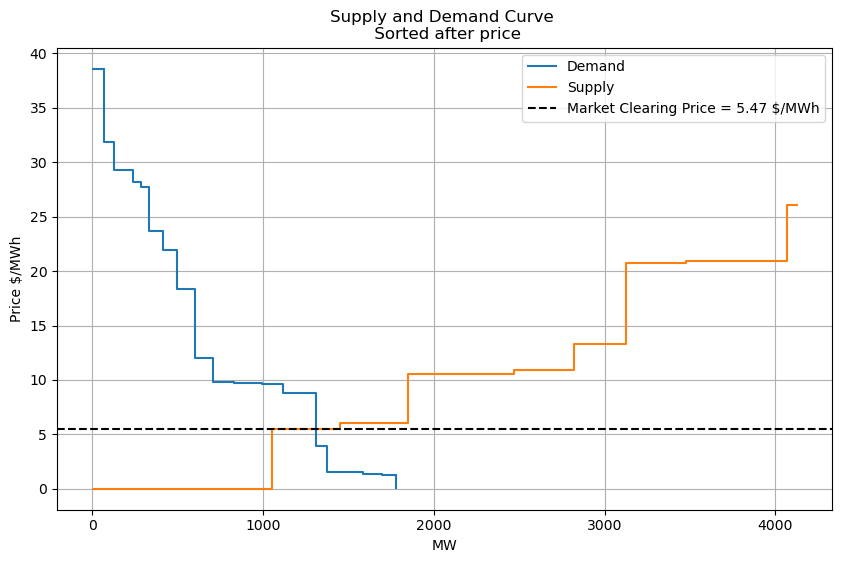

In [461]:
#sorting data for plotting the supply and demand curve
supply_data = [
    (Generation_price[i], VARIABLES[i], variables[VARIABLES[i]].X, Constraints_rhs[i])
    for i in range(len(VARIABLES))
]
supply_data_sorted = sorted(supply_data, key=lambda x: x[0])
sorted_prices = [x[0] for x in supply_data_sorted]
sorted_dispatch = [x[3] for x in supply_data_sorted] ### changed for plotting
cumulative_supply = np.cumsum(sorted_dispatch)

print(sorted_dispatch)

#plot the supply and demand curve
plt.figure(figsize=(10, 6))
plt.step(np.cumsum(Load), Demand_price, label='Demand')
plt.step(cumulative_supply, sorted_prices, label='Supply')

#plot purely for aestetic reason
plt.hlines(y=0, xmin=0, xmax=cumulative_supply[0], color='tab:orange')
plt.hlines(y=Demand_price[0], xmin=0, xmax=Load[0], color='tab:blue')
plt.vlines(x=np.cumsum(Load)[-1], ymin=0, ymax=np.min(Demand_price), color='tab:blue')

#plot marketclearing price
plt.axhline(y=Balance_constraint[0].Pi, color='black', linestyle='--', label=f'Market Clearing Price = {Balance_constraint[0].Pi:.2f} $/MWh')

#final plotting details
plt.xlabel('MW')
plt.ylabel('Price $/MWh')
plt.title('Supply and Demand Curve \n Sorted after price')
plt.legend()
plt.grid()
plt.show()





